In [57]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import pyaudio
import os
import serial
import time
from scipy import signal
import pickle
from winsound import PlaySound, SND_FILENAME, SND_ASYNC
import pyaudio
import wave
import scipy.io.wavfile as wav

# plt.close('all')

#Parámetros iniciales
formato = pyaudio.paInt16
canales = 1
tasa_muestreo = 44100
tamano_bloque = 1024
tiempo_grabacion = 2

# Referencias
# en = ["forward", "backward", "left", "right"]
en = ["forward", "backward", "left", "right"]
es = ["adelante", "atras", "izquierda", "derecha"]
com = ('00','11', '10', '01')

#FUnción para agregar nuevos audios a la base de datos
def add_db(tipo, muestra):
    directorio_base = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train"
    if not os.path.exists(directorio_base):
        os.makedirs(directorio_base)

    # Crear la subcarpeta para el tipo de audio si no existe
    subcarpeta = os.path.join(directorio_base, tipo)
    if not os.path.exists(subcarpeta):
        os.makedirs(subcarpeta)

    nombre_archivo = f"{tipo}_{muestra:02}.wav"
    ruta_archivo = os.path.join(subcarpeta, nombre_archivo)

    grabar_audio(ruta_archivo)

#Función para grabar audios dependiendo de los dispositivos disponibles
def grabar_audio(nombre_archivo):

    audio = pyaudio.PyAudio()
    print("Dispositivos disponibles:")
    for i in range(audio.get_device_count()):
        info = audio.get_device_info_by_index(i)
        print(f"ID: {i}, Nombre: {info['name']}")
    index_selected = int(input("Introduce el ID del micrófono a utilizar: "))

    try:
        flujo_sonido = audio.open(format=formato, channels=canales, rate=tasa_muestreo,
                                  input=True, frames_per_buffer=tamano_bloque, input_device_index=index_selected)
        print('Inicia la grabación')
        datos_audio = []
        fragmentos = []
        for i in range(0, int(tasa_muestreo / tamano_bloque * tiempo_grabacion)):
            datos_bloque = flujo_sonido.read(tamano_bloque, exception_on_overflow=False)
            datos_audio.append(datos_bloque)
            fragmentos.append(np.frombuffer(datos_bloque, dtype=np.int16))
        senal_audio = np.hstack(fragmentos)
        print('Termina la Grabación')

        if np.max(np.abs(senal_audio)) != 0:
            senal_audio = senal_audio / np.max(np.abs(senal_audio)) * 32767
            senal_audio = senal_audio.astype(np.int16)

        flujo_sonido.stop_stream()
        flujo_sonido.close()
    except Exception as e:
        print(f"Error durante la grabación: {e}")
        return None
    finally:
        audio.terminate()

    try:
        with wave.open(nombre_archivo, 'wb') as archivo_wave:
            archivo_wave.setnchannels(canales)
            archivo_wave.setsampwidth(audio.get_sample_size(formato))
            archivo_wave.setframerate(tasa_muestreo)
            archivo_wave.writeframes(b''.join([senal_audio.tobytes()]))
    except Exception as e:
        print(f"Error al guardar el archivo WAV: {e}")
        return None

    return senal_audio

#Caso contrario; Función para cargar un audio pregrabado
def cargar_audio(file_path):
    FS = 44100
    with wave.open(file_path, 'rb') as wav_file:
        params = wav_file.getparams()
        _, sample_width, frame_rate, n_frames, _, _ = params[:6]
        frames = wav_file.readframes(n_frames)
    dtype = np.int16 if sample_width == 2 else np.int32
    data = np.frombuffer(frames, dtype=dtype)
    if frame_rate != FS:
        rr = FS / frame_rate
        frame_rate = FS
        data = signal.resample(data, int(len(data) * rr))
    return data, frame_rate

#Función para enviar la instrucción al arduino
def sarduino(resultado):
    arduino.write(resultado.encode() + b'\n')
    return

#Función para entrenar la red
def Instar_Compet_Tr(patrones, W):
    pkl = 'pesos_bias.pkl'
    if os.path.exists(pkl):
        with open(pkl, 'rb') as f:
            data = pickle.load(f)
            W = data['W']
            bias = data['bias']
        print("Pesos y bias cargados desde el archivo pkl.")
    else:
        print("No se encontró el archivo pkl, se utilizarán los pesos iniciales.")
        bias = np.zeros(W.shape[0])

    epocas = 100000  # Número de épocas
    alpha = 0.0001

    for epoca in range(epocas):
        for i in range(patrones.shape[0]):
            a1 = np.dot(W, patrones[i, :].T) + bias
            ganador = np.argmax(a1)
            for j in range(W.shape[0]):
                if j == ganador:
                    W[j, :] += alpha * (patrones[i, :] - W[j, :])
            bias[ganador] -= 0.2 * (1 + bias[ganador])
        
        # print(W)
        if (epoca+1)%100==0:
            print(f"Época: {epoca}")
        with open(pkl, 'wb') as f:
            pickle.dump({'W': W, 'bias': bias}, f)

#FUnción para probar la red
# def Instar_Compet_Ts(patron):

#     pkl = 'pesos_bias.pkl'
#     if os.path.exists(pkl):
#         with open(pkl, 'rb') as f:
#             data = pickle.load(f)
#             W = data['W']
#             bias = data['bias']
#         print("Pesos y bias cargados desde el archivo pkl.")
#     else:
#         print("No se encontró el archivo pkl, favor de entrenar la red.")
#         return

#     epsilon = 0.1
#     iteracion = 100
#     print(patron)

#     # Iteración para el proceso de salida
#     a1 = np.dot(W, patron) + bias
#     a2 = a1.copy()
#     for _ in range(iteracion):
#         new_a2 = np.zeros_like(a2)
#         for i in range(len(a2)):
#             ini = epsilon * (np.sum(a2) - a2[i])
#             new_a2[i] = max(0, a2[i] - ini)
#         a2 = new_a2

#     winner_ind = np.argmax(a2)
#     print(f"Salida final: {a2}")
#     print(f"Combinación: {com[winner_ind]}")
    
#     return com[winner_ind]
import os
import pickle
import numpy as np

def Instar_Compet_Ts(patron):
    pkl ="pesos_bias.pkl"# r"C:\Users\emili\Downloads\pesos_bias.pkl"
    
    if os.path.exists(pkl):
        with open(pkl, 'rb') as f:
            data = pickle.load(f)
            weights_1 = data[0]  # Pesos de la primera capa
            bias_1 = data[1]     # Bias de la primera capa
            weights_2 = data[2]  # Pesos de la segunda capa
            bias_2 = data[3]     # Bias de la segunda capa
            weights_3 = data[4]  # Pesos de la tercera capa
            bias_3 = data[5]     # Bias de la tercera capa
        print("Pesos y bias cargados desde el archivo pkl.")
    else:
        print("No se encontró el archivo pkl, favor de entrenar la red.")
        return

    epsilon = 0.1
    iteracion = 50
    print(patron)

    # Propagación hacia adelante (Forward Propagation)
    a1 = np.dot(patron, weights_1) + bias_1
    a1 = np.maximum(0, a1)  # ReLU activación en la primera capa

    a2 = np.dot(a1, weights_2) + bias_2
    a2 = np.maximum(0, a2)  # ReLU activación en la segunda capa

    a3 = np.dot(a2, weights_3) + bias_3
    a3 = np.exp(a3 - np.max(a3))  # Softmax activación en la salida
    a3 = a3 / np.sum(a3)  # Normalización de salida

    # Proceso iterativo para obtener la salida final
    for _ in range(iteracion):
        new_a3 = np.zeros_like(a3)
        for i in range(len(a3)):
            ini = epsilon * (np.sum(a3) - a3[i])
            new_a3[i] = max(0, a3[i] - ini)
        a3 = new_a3

    winner_ind = np.argmax(a3)
    print(f"Salida final: {a3}")
    print(f"Combinación: {winner_ind}")
    
    # Mapeo a las combinaciones deseadas
    return com[winner_ind]


#Función para el filtrado y manejo de la señal por amplitudes y el ploteo de las señales
def preenfasis_y_graficos(senal, threshold=0.1, alpha=0.95):
    senal_normal = senal / np.max(np.abs(senal))
    if len(senal_normal.shape) > 1:
        senal_normal = senal_normal[:, 0]
    pre = np.roll(senal_normal, 1) - alpha * senal_normal
    pre[0] = 0
    pre = np.where(np.abs(pre) >= 0.9, 0, pre)

    # active_idx = np.where(np.abs(pre) > threshold)[0]
    # if len(active_idx) > 0:
    #     start_idx = active_idx[0]
    #     end_idx = active_idx[-1]
    #     pre_trimmed = pre[start_idx:end_idx + 1]
    # else:
    pre_trimmed = pre

    # if len(pre_trimmed) > 100:
    #     pre_trimmed = pre_trimmed[:100]
    # elif len(pre_trimmed) < 100:
    #     pre_trimmed = np.pad(pre_trimmed, (0, 100 - len(pre_trimmed)), mode='constant')

    # duration = len(pre) / tasa_muestreo
    # time = np.linspace(0, duration, len(pre))
    # time_trimmed = np.linspace(start_idx / tasa_muestreo, end_idx / tasa_muestreo, len(pre_trimmed))

    # plt.figure(figsize=(10, 5))
    # plt.subplot(3, 1, 1)
    # plt.plot(time, senal_normal)
    # plt.title('Señal normalizada')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.subplot(3, 1, 2)
    # plt.plot(time, pre)
    # plt.title('Señal pre-enfasis')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.subplot(3, 1, 3)
    # plt.plot(time_trimmed, pre_trimmed)
    # plt.title('Señal recortada')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.tight_layout()
    # plt.show()
    return pre_trimmed

#Función para el cálculo de energía y cruces por cero
def ener_ZCR(sig,Fs):
    win_dur = 0.02  
    # Parámetros de la ventana y pasos
    win_len = int(win_dur * Fs)
    step = win_len
    n_windows = int(np.ceil((len(sig) - win_len) / step)) + 1
    # Rellenar señal
    pad_len = n_windows * step + win_len
    sig = np.append(sig, np.zeros(pad_len - len(sig)))


    # Cálculo de energía y ZCR
    eng = []
    zcr = []
    for i in range(n_windows):
        start = i * step
        end = start + win_len
        win = sig[start:end]
        eng.append(np.sum(win ** 2))
        zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)  
    
    feats = np.concatenate((eng, zcr))
    feats= feats/np.max(np.abs(feats))
    return feats

#FUnción para realizar la base de datos
def DB():
    audio_dir = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train"

    proto_files = []
    for root, _, files in os.walk(audio_dir):
        for file in files:
            if file.endswith('.wav'):
                proto_files.append(os.path.join(root, file))

    subcarpeta_feats = {}

    for root, dirs, files in os.walk(audio_dir):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                Fs, sig = wav.read(file_path)

                # Normalizar y aplicar preénfasis
                sig = preenfasis_y_graficos(sig)
                feats= ener_ZCR(sig,Fs)
                subcarpeta = os.path.basename(root)  
                
                # Añadir características a la lista correspondiente de la subcarpeta
                if subcarpeta not in subcarpeta_feats:
                    subcarpeta_feats[subcarpeta] = []
                subcarpeta_feats[subcarpeta].append(feats)

    centroides = []

    for subcarpeta, feats_list in subcarpeta_feats.items():
        # # Encontrar la longitud máxima entre los vectores de características
        # max_length = max(len(feats) for feats in feats_list)
        
        # # Rellenar cada vector con ceros al final para igualar longitudes
        # padded_feats = [np.pad(feats, (0, max_length - len(feats)), mode='constant') for feats in feats_list]
        
        # Calcular el centroide (promedio) de las características para esta subcarpeta
        centroid = np.mean(feats_list, axis=0)
        
        # Guardar el centroide
        centroides.append(centroid)

    # Convertir los centroides a un arreglo numpy
    W = np.array(centroides, dtype=np.float64)
    print(W)
    print(W.size)
    # print(f"Prototipos: {proto_feats}")
    print(subcarpeta_feats)
    return W,subcarpeta_feats

#Menú Principal e implementación
arduino = None
while True:
    print("\n=== Menú Principal ===")
    print("\nSelecciona una opción:")
    print("0. Vincular Arduino")
    print("1. Grabar audio en tiempo real")
    print("2. Cargar archivo de audio pregrabado")
    print("3. Agregar audio a base de datos")
    print("4. Determinar pesos sinápticos")
    print("5. Entrenar Red")
    print("6. Salir")
    opcion = input("Opción: ")

    if opcion == "0":
        if arduino and arduino.is_open:
            arduino.close()
        try:
            arduino = serial.Serial('COM16', 115200, timeout=2, dsrdtr=True)
            time.sleep(2)
            print("Conexión exitosa.")
        except serial.SerialException as e:
            print(f"Error al conectar con Arduino: {e}")

    elif opcion == "1":
        # print("Grabando audio...")
        nombre_archivo = 'audio_grabado.wav'
        formato = pyaudio.paInt16
        canales = 1
        tasa_muestreo = 44100
        tamano_bloque = 1024
        tiempo_grabacion = 2
        senal = grabar_audio(nombre_archivo)
        if senal is not None:
            sig=preenfasis_y_graficos(senal)

        feats= ener_ZCR(sig,tasa_muestreo)
        res=Instar_Compet_Ts(feats)
        print(res)
        sarduino(res)

    elif opcion == "2":
        file_path = input("Introduce la ruta del archivo WAV: ").strip().strip('"')
        if os.path.exists(file_path):
            senal, tasa_muestreo = cargar_audio(file_path)
            sig=preenfasis_y_graficos(senal)
            feats= ener_ZCR(sig,tasa_muestreo)
            res=Instar_Compet_Ts(feats)
            sarduino(res)
        else:
            print("El archivo no existe. Intenta de nuevo.")

    elif opcion == "3":
        while True:
            print("\n=== Menú de Grabación ===")
            print("1. Grabar inglés")
            print("2. Grabar español")
            print("3. Salir\n")
            opcion = input("Selecciona una opción: ")
            if opcion == "1":
                print("1. Grabar forward")
                print("2. Grabar backward")
                print("3. Grabar left")
                print("4. Grabar right")
                print("5. Volver")

                opcion = input("Selecciona una opción: ")

                if opcion in ["1", "2", "3", "4"]:
                    tipo = en[int(opcion) - 1]
                    muestra = int(input(f"Introduce el número de muestra para {tipo}: "))
                    add_db(tipo, muestra)
                elif opcion == "5":
                    print("Volviendo al menú anterior...")
                    continue
                else:
                    print("Opción no válida. Intenta de nuevo.")
            elif opcion=="2":
                print("1. Grabar adelante")
                print("2. Grabar atras")
                print("3. Grabar izquierda")
                print("4. Grabar derecha")
                print("5. Volver")

                opcion = input("Selecciona una opción: ")

                if opcion in ["1", "2", "3", "4"]:
                    tipo = es[int(opcion) - 1]
                    muestra = int(input(f"Introduce el número de muestra para {tipo}: "))
                    add_db(tipo, muestra)
                elif opcion == "5":
                    print("Volviendo al menú anterior...")
                    continue
                else:
                    print("Opción no válida. Intenta de nuevo.")
            elif opcion == "3":
                print("Saliendo al menú principal...")
                break

    elif opcion == "4":
        W,patronesdb=DB()

    elif opcion == "5":
        valores = []
        # print(patronesdb)
        for key, feats_list in patronesdb.items():
            for feats in feats_list:
                valores.append(feats)
        
        # # Encuentra la longitud máxima de las características
        # max_length = max(len(feats) for feats in valores)
        
        # # Normaliza las características rellenando con ceros al final
        # valores_normalizados = [
        #     np.pad(feats, (0, max_length - len(feats)), mode='constant') for feats in valores
        # ]
        
        # Convierte la lista de características a un array NumPy
        patrones = np.array(valores, dtype=np.float64)
        # print(f"Forma de patrones para entrenamiento: {patrones.shape}")
        print(patrones)
        # Instar_Compet_Tr(patrones, W)
        Instar_Compet_Tr(patrones,W)

    elif opcion == "6":
        if arduino and arduino.is_open:
          arduino.close()
        print("Saliendo...")
        break
    else:
        print("Opción no válida. Intenta de nuevo.")


=== Menú Principal ===

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Agregar audio a base de datos
4. Determinar pesos sinápticos
5. Entrenar Red
6. Salir
Conexión exitosa.

=== Menú Principal ===

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Agregar audio a base de datos
4. Determinar pesos sinápticos
5. Entrenar Red
6. Salir
Pesos y bias cargados desde el archivo pkl.
[2.36457010e-06 2.30501163e-06 1.96438783e-05 4.46862936e-06
 3.03232679e-06 1.52393218e-06 2.07788089e-06 1.36571369e-06
 1.88177062e-06 1.54727100e-06 1.41804994e-06 1.71341717e-06
 1.76214378e-06 1.57259624e-06 1.61085609e-06 1.97074561e-06
 1.85771924e-06 1.67509396e-06 1.88898767e-06 1.21048276e-05
 1.94566764e-06 1.77183199e-06 2.07931270e-06 1.88818322e-06
 1.64904170e-06 1.63777267e-06 1.62731193e-06 1.62140007e-06
 1.35742833e-06 1.58689661e-06 1.70618264e-06 1.60519541e-0

In [46]:
with open(r"C:\Users\emili\Downloads\pesos_bias.pkl", 'rb') as f:
    data = pickle.load(f)
    content = f.read()
    print(content) 

W = data[0]
bias = data[1]
    

b''


KeyError: 0

In [55]:
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile as wav
import pickle


def preenfasis_y_graficos(senal, threshold=0.02, alpha=0.95):
    senal_normal = senal / np.max(np.abs(senal))
    if len(senal_normal.shape) > 1:
        senal_normal = senal_normal[:, 0]
    pre = np.roll(senal_normal, 1) - alpha * senal_normal
    pre[0] = 0
    pre = np.where(np.abs(pre) >= 0.9, 0, pre)
    pre_trimmed = pre

    # active_idx = np.where(np.abs(pre) > threshold)[0]
    # if len(active_idx) > 0:
    #     start_idx = active_idx[0]
    #     end_idx = active_idx[-1]
    # #     pre_trimmed = pre[start_idx:end_idx + 1]
    # # else:
    # #     pre_trimmed = pre
    

    # # if len(pre_trimmed) > 100:
    # #     pre_trimmed = pre_trimmed[:100]
    # # elif len(pre_trimmed) < 100:
    # #     pre_trimmed = np.pad(pre_trimmed, (0, 100 - len(pre_trimmed)), mode='constant')

    # duration = len(pre) / tasa_muestreo
    # time = np.linspace(0, duration, len(pre))
    # time_trimmed = np.linspace(start_idx / tasa_muestreo, end_idx / tasa_muestreo, len(pre_trimmed))

    # plt.figure(figsize=(10, 5))
    # plt.subplot(3, 1, 1)
    # plt.plot(time, senal_normal)
    # plt.title('Señal normalizada')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.subplot(3, 1, 2)
    # plt.plot(time, pre)
    # plt.title('Señal pre-enfasis')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.subplot(3, 1, 3)
    # plt.plot(time_trimmed, pre_trimmed)
    # plt.title('Señal recortada')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.tight_layout()
    # # plt.show()
    return pre_trimmed

#Función para el cálculo de energía y cruces por cero
def ener_ZCR(sig,Fs):
    win_dur = 0.02  
    # Parámetros de la ventana y pasos
    win_len = int(win_dur * Fs)
    step = win_len
    n_windows = int(np.ceil((len(sig) - win_len) / step)) + 1
    # Rellenar señal
    pad_len = n_windows * step + win_len
    sig = np.append(sig, np.zeros(pad_len - len(sig)))


    # Cálculo de energía y ZCR
    eng = []
    zcr = []
    for i in range(n_windows):
        start = i * step
        end = start + win_len
        win = sig[start:end]
        eng.append(np.sum(win ** 2))
        zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)  
    
    feats = np.concatenate((eng, zcr))
    feats= feats/np.max(np.abs(feats))
    return feats


def procesar_audios(audio_dir):
    """
    Procesa archivos de audio en carpetas y subcarpetas para generar un vector de características similar a vecte.

    Parámetros:
    - audio_dir: Ruta principal donde se encuentran las carpetas con los archivos de audio.

    Retorna:
    - vecte_df: DataFrame con las características y etiquetas correspondientes.
    """
    datos = []

    # Recorrer las carpetas y subcarpetas para procesar archivos .wav
    for root, dirs, files in os.walk(audio_dir):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                Fs, sig = wav.read(file_path)

                # Normalizar y aplicar preénfasis (reemplazar con tus funciones específicas)
                sig = preenfasis_y_graficos(sig)
                feats = ener_ZCR(sig, Fs)

                # Obtener etiqueta desde el nombre de la carpeta
                etiqueta = os.path.basename(root)

                # Agregar características y etiqueta a los datos
                datos.append([etiqueta] + list(feats))

    # Convertir los datos a un DataFrame similar a vecte
    columnas = ["Etiqueta"] + [f"Caracteristica_{i+1}" for i in range(len(feats))]
    vecte_df = pd.DataFrame(datos, columns=columnas)
    return vecte_df

def mapear_etiquetas(vecte_df):
    """
    Convierte etiquetas no numéricas a valores numéricos.

    Parámetros:
    - vecte_df: DataFrame con etiquetas no numéricas.

    Retorna:
    - vecte_df: DataFrame con etiquetas numéricas.
    - etiqueta_mapeo: Diccionario con el mapeo etiqueta -> valor numérico.
    """
    etiquetas_unicas = vecte_df["Etiqueta"].unique()
    etiqueta_mapeo = {etiqueta: idx for idx, etiqueta in enumerate(etiquetas_unicas)}
    vecte_df["Etiqueta"] = vecte_df["Etiqueta"].map(etiqueta_mapeo)
    return vecte_df, etiqueta_mapeo

# Definir funciones de activación y sus respectivas derivadas
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def softmax(x):
    exp_x = np.exp(x - np.max(x)) 
    if x.ndim == 1:
        return exp_x / exp_x.sum()  # Para vectores unidimensionales
    else:
        return exp_x / exp_x.sum(axis=1, keepdims=True)  # Para matrices 2D

# Función de pérdida: Categorical Crossentropy
def categorical_crossentropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))  # Añadir epsilon para estabilidad numérica

# Backpropagation
def update_weights(weights, biases, d_weights, d_biases, learning_rate):
    weights -= learning_rate * d_weights
    biases -= learning_rate * np.sum(d_biases, axis=0)  # Asegurar que el bias tenga la forma correcta
    return weights, biases

def guardar_modelo(weights_1, bias_1, weights_2, bias_2, weights_3, bias_3, filename="pesos_bias.pkl"):
    with open(filename, 'wb') as f:
        pickle.dump((weights_1, bias_1, weights_2, bias_2, weights_3, bias_3), f)
    print(f"Modelo guardado en {filename}")

def cargar_modelo(filename="pesos_bias.pkl"):
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            weights_1, bias_1, weights_2, bias_2, weights_3, bias_3 = pickle.load(f)
        print(f"Modelo cargado desde {filename}")
        return weights_1, bias_1, weights_2, bias_2, weights_3, bias_3
    else:
        return None

# Entrenamiento con Backpropagation
def BackPropagation(weights_1, bias_1, weights_2, bias_2, weights_3, bias_3, vecte_df):
    X_train = vecte_df.iloc[:, 1:].values.astype(float)
    y_train = vecte_df.iloc[:, 0].values.astype(int)
    y_train_one_hot = np.eye(4)[y_train]  # Convertir la etiqueta a one-hot encoding

    # Normalización de los vectores de entrenamiento
    X_train = X_train / 255.0

    # Parámetros del entrenamiento
    epochs = 1 #
    learning_rate = 0.1
    batch_size = 1

    for epoch in range(epochs):
        print(f"--- Época {epoch + 1}/{epochs} ---")
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train[i:i + batch_size]
            y_batch = y_train_one_hot[i:i + batch_size]

            # Forward Propagation
            z1 = np.dot(X_batch, weights_1) + bias_1
            a1 = relu(z1)

            z2 = np.dot(a1, weights_2) + bias_2
            a2 = relu(z2)

            z3 = np.dot(a2, weights_3) + bias_3
            output = softmax(z3)

            loss = categorical_crossentropy(y_batch, output)

            # Backpropagation
            d_z3 = output - y_batch
            d_weights_3 = np.dot(a2.T, d_z3)
            d_bias_3 = d_z3

            d_a2 = np.dot(d_z3, weights_3.T)
            d_z2 = d_a2 * relu_derivative(a2)
            d_weights_2 = np.dot(a1.T, d_z2)
            d_bias_2 = d_z2

            d_a1 = np.dot(d_z2, weights_2.T)
            d_z1 = d_a1 * relu_derivative(a1)
            d_weights_1 = np.dot(X_batch.T, d_z1)
            d_bias_1 = d_z1

            # Actualizar pesos y biases
            weights_3, bias_3 = update_weights(weights_3, bias_3, d_weights_3, d_bias_3, learning_rate)
            weights_2, bias_2 = update_weights(weights_2, bias_2, d_weights_2, d_bias_2, learning_rate)
            weights_1, bias_1 = update_weights(weights_1, bias_1, d_weights_1, d_bias_1, learning_rate)

        print(f"Fin de la época {epoch + 1}/{epochs}, última pérdida: {loss}")

    print("Entrenamiento completado.")
        
# Guardar el modelo después de entrenar
    guardar_modelo(weights_1, bias_1, weights_2, bias_2, weights_3, bias_3)
    return weights_1, bias_1, weights_2, bias_2, weights_3, bias_3

# Declaración de los pesos y bias de la red neuronal de 3 capas
np.random.seed(42)
s1 = 128
s2 = 64
s3 = 4

# Intentar cargar el modelo guardado
modelo_cargado = cargar_modelo()

if modelo_cargado:
    weights_1, bias_1, weights_2, bias_2, weights_3, bias_3 = modelo_cargado
else:
    weights_1 = np.random.randn(200, s1)
    bias_1 = np.random.randn(s1)

    weights_2 = np.random.randn(s1, s2)
    bias_2 = np.random.randn(s2)

    weights_3 = np.random.randn(s2, s3)
    bias_3 = np.random.randn(s3)

# Procesar audios para generar vecte_df similar al CSV
audio_dir = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train"
vecte_df = procesar_audios(audio_dir)

# Mapear etiquetas a valores numéricos
vecte_df, etiqueta_mapeo = mapear_etiquetas(vecte_df)

while True:
    weights_1, bias_1, weights_2, bias_2, weights_3, bias_3 = BackPropagation(weights_1, bias_1, weights_2, bias_2, weights_3, bias_3, vecte_df)

    continuar = input("¿Deseas entrenar de nuevo? (s/n): ")
    if continuar.lower() != 's':
        break


--- Época 1/1 ---
Fin de la época 1/1, última pérdida: 3.269570789825481e-08
Entrenamiento completado.
Modelo guardado en pesos_bias.pkl


In [44]:
pkl="pesos_bias.pkl"
with open(pkl, 'rb') as f:
            data = pickle.load(f)
            W = data[4]
            bias = data[5]

W


array([[-0.0820325 ,  0.42718547,  0.20568892, -0.54125957],
       [ 1.03361284,  0.79693256, -1.77428419, -0.23024267],
       [-1.08028679, -1.2680581 ,  0.53513362, -0.41926128],
       [-0.14277165, -0.66968493,  0.37017545,  0.67834689],
       [ 2.17027332, -0.18079255, -1.44857738, -0.50393396],
       [ 0.46723535, -0.30778839, -1.49468061, -0.82429692],
       [-0.53336592, -1.08266955,  0.21747651, -0.07902228],
       [ 0.78970524, -0.44585983,  0.55806477, -0.49227079],
       [-1.12961236, -0.54301914, -1.61826719,  1.78821564],
       [-0.07143769, -0.90450464, -0.14965296, -2.35542   ],
       [ 1.1641451 ,  1.33808836,  0.37080146,  0.32487055],
       [-1.26767678, -1.1949699 , -1.69729615, -0.16106809],
       [ 1.16089681, -0.24751333,  0.21754357,  0.87342344],
       [-1.40046583,  1.56960855,  1.26736851,  0.45616661],
       [ 0.85025276,  1.14381898,  0.30690484,  1.3151121 ],
       [-0.7463929 ,  0.21138921,  1.41643281, -2.24183523],
       [ 0.43796335,  0.


=== Menú Principal ===

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Agregar audio a base de datos
4. Determinar pesos sinápticos
5. Entrenar Red
6. Salir


[[0.4006639  0.30710213 0.46196121 ... 0.34541753 0.08060327 0.2524085 ]
 [0.31743876 0.46390846 0.30085906 ... 0.35291407 0.31333629 0.24303941]
 [0.07271574 0.02920111 0.46453438 ... 0.27268094 0.43412845 0.3218686 ]
 [0.26558458 0.3423899  0.1410634  ... 0.19528932 0.44568435 0.47306604]]
2000
{'este': [array([7.17166689e-05, 5.99898971e-04, 1.20233100e-03, 1.38350671e-03,
       1.05726800e-03, 8.00944507e-04, 8.36597541e-04, 8.41076301e-04,
       9.32475466e-04, 7.85791070e-04, 8.76970570e-04, 9.30816579e-04,
       7.97464422e-04, 8.70015783e-04, 9.13197155e-04, 7.92527828e-04,
       8.54076251e-04, 8.40408308e-04, 8.65703350e-04, 8.06707999e-04,
       7.75644947e-04, 8.34979191e-04, 8.83462421e-04, 7.72796661e-04,
       3.82990689e-03, 6.72804302e-02, 1.96105252e-01, 4.34753283e-01,
       8.64926554e-01, 8.67813810e-01, 1.00000000e+00, 2.83833934e-01,
       3.80814537e-01, 5.57046708e-01, 5.47648532e-01, 5.32186487e-01,
       6.70243601e-01, 2.65658786e-01, 1.83160993e-02

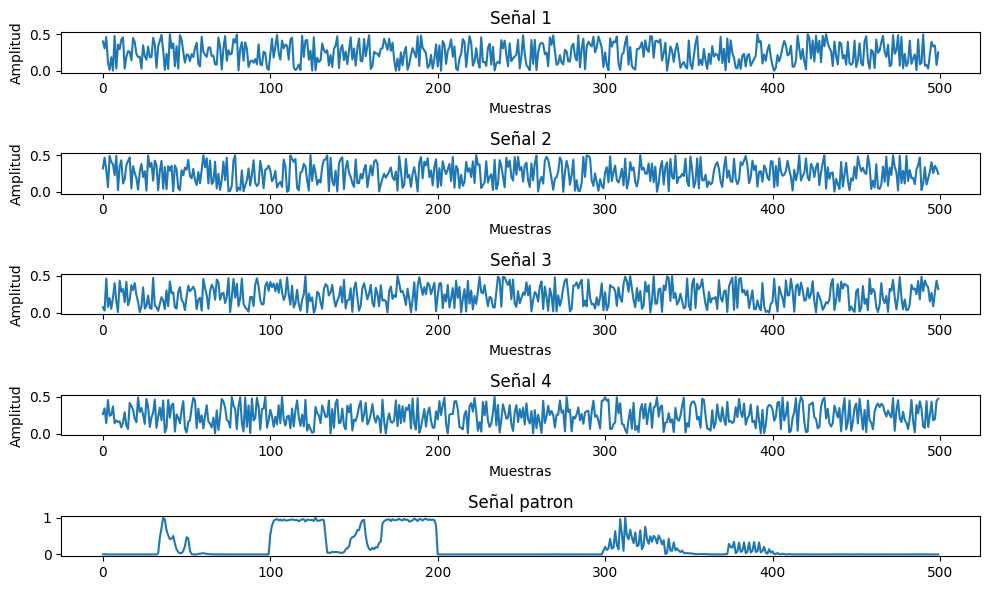


=== Menú Principal ===

Selecciona una opción:
0. Vincular Arduino
1. Grabar audio en tiempo real
2. Cargar archivo de audio pregrabado
3. Agregar audio a base de datos
4. Determinar pesos sinápticos
5. Entrenar Red
6. Salir
Saliendo...


In [8]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import pyaudio
import os
import serial
import time
from scipy import signal
import pickle
from winsound import PlaySound, SND_FILENAME, SND_ASYNC
import pyaudio
import wave
import scipy.io.wavfile as wav

# plt.close('all')

#Parámetros iniciales
formato = pyaudio.paInt16
canales = 1
tasa_muestreo = 44100
tamano_bloque = 1024
tiempo_grabacion = 2

# Referencias
# en = ["forward", "backward", "left", "right"]
en = ["forward", "backward", "left", "right"]
es = ["adelante", "atras", "izquierda", "derecha"]
# com = ("izquierda", "adelante", "11", "derecha", "00", "atras","10", "01")#('00','11', '10', '01')
com = ('00','11', '10', '01')


#FUnción para agregar nuevos audios a la base de datos
def add_db(tipo, muestra):
    directorio_base = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train"
    if not os.path.exists(directorio_base):
        os.makedirs(directorio_base)

    # Crear la subcarpeta para el tipo de audio si no existe
    subcarpeta = os.path.join(directorio_base, tipo)
    if not os.path.exists(subcarpeta):
        os.makedirs(subcarpeta)

    nombre_archivo = f"{tipo}_{muestra:02}.wav"
    ruta_archivo = os.path.join(subcarpeta, nombre_archivo)

    grabar_audio(ruta_archivo)

#Función para grabar audios dependiendo de los dispositivos disponibles
def grabar_audio(nombre_archivo):

    audio = pyaudio.PyAudio()
    print("Dispositivos disponibles:")
    for i in range(audio.get_device_count()):
        info = audio.get_device_info_by_index(i)
        print(f"ID: {i}, Nombre: {info['name']}")
    index_selected = int(input("Introduce el ID del micrófono a utilizar: "))

    try:
        flujo_sonido = audio.open(format=formato, channels=canales, rate=tasa_muestreo,
                                  input=True, frames_per_buffer=tamano_bloque, input_device_index=index_selected)
        print('Inicia la grabación')
        datos_audio = []
        fragmentos = []
        for i in range(0, int(tasa_muestreo / tamano_bloque * tiempo_grabacion)):
            datos_bloque = flujo_sonido.read(tamano_bloque, exception_on_overflow=False)
            datos_audio.append(datos_bloque)
            fragmentos.append(np.frombuffer(datos_bloque, dtype=np.int16))
        senal_audio = np.hstack(fragmentos)
        print('Termina la Grabación')

        if np.max(np.abs(senal_audio)) != 0:
            senal_audio = senal_audio / np.max(np.abs(senal_audio)) * 32767
            senal_audio = senal_audio.astype(np.int16)

        flujo_sonido.stop_stream()
        flujo_sonido.close()
    except Exception as e:
        print(f"Error durante la grabación: {e}")
        return None
    finally:
        audio.terminate()

    try:
        with wave.open(nombre_archivo, 'wb') as archivo_wave:
            archivo_wave.setnchannels(canales)
            archivo_wave.setsampwidth(audio.get_sample_size(formato))
            archivo_wave.setframerate(tasa_muestreo)
            archivo_wave.writeframes(b''.join([senal_audio.tobytes()]))
    except Exception as e:
        print(f"Error al guardar el archivo WAV: {e}")
        return None
    
    PlaySound(nombre_archivo,SND_FILENAME|SND_ASYNC)


    return senal_audio

#Caso contrario; Función para cargar un audio pregrabado
def cargar_audio(file_path):
    FS = 44100
    with wave.open(file_path, 'rb') as wav_file:
        params = wav_file.getparams()
        _, sample_width, frame_rate, n_frames, _, _ = params[:6]
        frames = wav_file.readframes(n_frames)
    dtype = np.int16 if sample_width == 2 else np.int32
    data = np.frombuffer(frames, dtype=dtype)
    if frame_rate != FS:
        rr = FS / frame_rate
        frame_rate = FS
        data = signal.resample(data, int(len(data) * rr))
    return data, frame_rate

#Función para enviar la instrucción al arduino
def sarduino(resultado):
    arduino.write(resultado.encode() + b'\n')
    return

#Función para entrenar la red
def Instar_Compet_Tr(patrones, W):
    pkl = 'pesos_bias.pkl'
    if os.path.exists(pkl):
        with open(pkl, 'rb') as f:
            data = pickle.load(f)
            W = data['W']
            bias = data['bias']
        print("Pesos y bias cargados desde el archivo pkl.")
    else:
        print("No se encontró el archivo pkl, se utilizarán los pesos iniciales.")
        bias = np.zeros(W.shape[0])

    epocas = 10000 # Número de épocas
    alpha = 0.0001

    for epoca in range(epocas):
        # alpha=alpha*0.9
        for i in range(patrones.shape[0]):
            a1 = np.dot(W, patrones[i, :].T) + bias #np.linalg.norm(W - patrones[i, :], axis=1)
            ganador = np.argmax(a1)
            for j in range(W.shape[0]):
                if j == ganador:
                    W[j, :] += alpha * (patrones[i, :] - W[j, :])
            bias[ganador] -= 0.2 * (1 + bias[ganador])
        
        # print(W)
        if (epoca)%100==0:
            print(f"Época: {epoca}")
        with open(pkl, 'wb') as f:
            pickle.dump({'W': W, 'bias': bias}, f)

#FUnción para probar la red
def Instar_Compet_Ts(patron):

    pkl = 'pesos_bias.pkl'#r"C:\Users\emili\Downloads\pesos_bias.pkl"#
    if os.path.exists(pkl):
        with open(pkl, 'rb') as f:
            data = pickle.load(f)
            W = data['W']
            bias = data['bias']
        print("Pesos y bias cargados desde el archivo pkl.")
    else:
        print("No se encontró el archivo pkl, favor de entrenar la red.")
        return

    epsilon = 0.01
    iteracion = 100
    print(patron)

    # Iteración para el proceso de salida
    a1 = np.dot(W, patron) + bias
    a2 = a1.copy()
    for _ in range(iteracion):
        new_a2 = np.zeros_like(a2)
        for i in range(len(a2)):
            ini = epsilon * (np.sum(a2) - a2[i])
            new_a2[i] = max(0, a2[i] - ini)
        a2 = new_a2

    winner_ind = np.argmax(a2)
    print(f"Salida final: {a2}")
    print(f"Combinación: {com[winner_ind]}")

    # Graficar las señales
    plt.figure(figsize=(10, 6))

    # Crear un subplot para cada señal
    for i in range(W.shape[0]):
        plt.subplot(5, 1, i+1)  # 4 filas y 1 columna
        plt.plot(W[i, :])
        plt.title(f'Señal {i+1}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')

    plt.subplot(5,1,5)
    plt.title(f'Señal patron')
    plt.plot(patron)

    plt.tight_layout()
    plt.show()
    
    return com[winner_ind]

#Función para el filtrado y manejo de la señal por amplitudes y el ploteo de las señales
def preenfasis_y_graficos(senal, threshold=0.02, alpha=0.95):
    senal_normal = senal / np.max(np.abs(senal))
    if len(senal_normal.shape) > 1:
        senal_normal = senal_normal[:, 0]
    pre = np.roll(senal_normal, 1) - alpha * senal_normal
    pre[0] = 0
    pre = np.where(np.abs(pre) >= 0.9, 0, pre)
    pre_trimmed = pre

    # active_idx = np.where(np.abs(pre) > threshold)[0]
    # if len(active_idx) > 0:
    #     start_idx = active_idx[0]
    #     end_idx = active_idx[-1]
    # #     pre_trimmed = pre[start_idx:end_idx + 1]
    # # else:
    # #     pre_trimmed = pre
    

    # # if len(pre_trimmed) > 100:
    # #     pre_trimmed = pre_trimmed[:100]
    # # elif len(pre_trimmed) < 100:
    # #     pre_trimmed = np.pad(pre_trimmed, (0, 100 - len(pre_trimmed)), mode='constant')

    # duration = len(pre) / tasa_muestreo
    # time = np.linspace(0, duration, len(pre))
    # time_trimmed = np.linspace(start_idx / tasa_muestreo, end_idx / tasa_muestreo, len(pre_trimmed))

    # plt.figure(figsize=(10, 5))
    # plt.subplot(3, 1, 1)
    # plt.plot(time, senal_normal)
    # plt.title('Señal normalizada')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.subplot(3, 1, 2)
    # plt.plot(time, pre)
    # plt.title('Señal pre-enfasis')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.subplot(3, 1, 3)
    # plt.plot(time_trimmed, pre_trimmed)
    # plt.title('Señal recortada')
    # plt.xlabel('Tiempo [s]')
    # plt.ylabel('Amplitud')

    # plt.tight_layout()
    # # plt.show()
    return pre_trimmed

#Función para el cálculo de energía y cruces por cero
def ener_ZCR(sig, Fs, freq_min=150, freq_max=300):  
    win_dur = 0.02  
    # Parámetros de la ventana y pasos
    win_len = int(win_dur * Fs)
    step = win_len
    n_windows = int(np.ceil((len(sig) - win_len) / step)) + 1
    # Rellenar señal
    pad_len = n_windows * step + win_len
    sig = np.append(sig, np.zeros(pad_len - len(sig)))

    # Calcular energía, ZCR y FFT
    eng = []
    zcr = []
    fft_concat = []  # Vector para almacenar todas las FFT concatenadas

    # Índices de las frecuencias mínima y máxima en la FFT
    freq_max = freq_max if freq_max is not None else Fs / 2  # Por defecto hasta Nyquist
    f_min_idx = int(freq_min / (Fs / win_len))
    f_max_idx = int(freq_max / (Fs / win_len))

    for i in range(n_windows):
        start = i * step
        end = start + win_len
        win = sig[start:end]
        eng.append(np.sum(win ** 2))
        zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)  
        
        fft_win = np.abs(np.fft.fft(win))[f_min_idx:f_max_idx]  # Seleccionar frecuencias en el rango
        fft_concat.extend(fft_win)

    # Normalización
    eng = np.array(eng) / np.max(np.abs(eng))
    zcr = np.array(zcr) / np.max(np.abs(zcr))
    fft_concat = np.array(fft_concat) / np.max(np.abs(fft_concat))

    # Concatenar características
    feats = np.concatenate((eng, zcr, fft_concat))
    
    # fft=fft/np.max(np.abs(fft))
    # eng=eng/np.max(np.abs(eng))
    # zcr=zcr/np.max(np.abs(zcr))
    # feats = np.concatenate((eng,zcr,fft))
    # plt.figure()
    # plt.plot(eng)
    # plt.figure()
    # plt.plot(zcr)
    # plt.figure
    # plt.plot(fft_concat)
    # plt.figure
    # plt.plot(feats)
    # feats=feats.flatten()
    # feats = eng
    # feats = zcr
    # feats=fft
    # feats= feats/np.max(np.abs(feats))
    return feats

#FUnción para realizar la base de datos
def DB():
    audio_dir = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train"

    proto_files = []
    for root, _, files in os.walk(audio_dir):
        for file in files:
            if file.endswith('.wav'):
                proto_files.append(os.path.join(root, file))

    subcarpeta_feats = {}

    for root, dirs, files in os.walk(audio_dir):
        # plt.show()
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                Fs, sig = wav.read(file_path)

                # Normalizar y aplicar preénfasis
                sig = preenfasis_y_graficos(sig)
                feats= ener_ZCR(sig,Fs)
                subcarpeta = os.path.basename(root)  
                
                # Añadir características a la lista correspondiente de la subcarpeta
                if subcarpeta not in subcarpeta_feats:
                    subcarpeta_feats[subcarpeta] = []
                subcarpeta_feats[subcarpeta].append(feats)

    centroides = []

    for subcarpeta, feats_list in subcarpeta_feats.items():
        # # Encontrar la longitud máxima entre los vectores de características
        # max_length = max(len(feats) for feats in feats_list)
        
        # # Rellenar cada vector con ceros al final para igualar longitudes
        # padded_feats = [np.pad(feats, (0, max_length - len(feats)), mode='constant') for feats in feats_list]
        
        # Calcular el centroide (promedio) de las características para esta subcarpeta
        # centroid = np.mean(feats_list, axis=0)
        centroid = feats_list[0]
        
        # Guardar el centroide
        centroides.append(centroid)

    # Convertir los centroides a un arreglo numpy
    W = np.array(centroides, dtype=np.float64)
    W = np.random.uniform(0, 0.5, size=W.shape)
    bias = np.ones(W.shape[0])
    pkl = 'pesos_bias.pkl'
    print(W)
    print(W.size)
    # print(f"Prototipos: {proto_feats}")
    print(subcarpeta_feats)
    with open(pkl, 'wb') as f:
        pickle.dump({'W': W, 'bias': bias}, f)
    return W,subcarpeta_feats

#Menú Principal e implementación
arduino = None
while True:
    print("\n=== Menú Principal ===")
    print("\nSelecciona una opción:")
    print("0. Vincular Arduino")
    print("1. Grabar audio en tiempo real")
    print("2. Cargar archivo de audio pregrabado")
    print("3. Agregar audio a base de datos")
    print("4. Determinar pesos sinápticos")
    print("5. Entrenar Red")
    print("6. Salir")
    opcion = input("Opción: ")

    if opcion == "0":
        if arduino and arduino.is_open:
            arduino.close()
        try:
            arduino = serial.Serial('COM16', 115200, timeout=2, dsrdtr=True)
            time.sleep(2)
            print("Conexión exitosa.")
        except serial.SerialException as e:
            print(f"Error al conectar con Arduino: {e}")

    elif opcion == "1":
        # print("Grabando audio...")
        nombre_archivo = 'audio_grabado.wav'
        formato = pyaudio.paInt16
        canales = 1
        tasa_muestreo = 44100
        tamano_bloque = 1024
        tiempo_grabacion = 2
        senal = grabar_audio(nombre_archivo)
        if senal is not None:
            sig=preenfasis_y_graficos(senal)

        feats= ener_ZCR(sig,tasa_muestreo)
        res=Instar_Compet_Ts(feats)
        print(res)
        # sarduino(res)

    elif opcion == "2":
        file_path = input("Introduce la ruta del archivo WAV: ").strip().strip('"')
        if os.path.exists(file_path):
            senal, tasa_muestreo = cargar_audio(file_path)
            sig=preenfasis_y_graficos(senal)
            feats= ener_ZCR(sig,tasa_muestreo)
            res=Instar_Compet_Ts(feats)
            # sarduino(res)
        else:
            print("El archivo no existe. Intenta de nuevo.")

    elif opcion == "3":
        while True:
            print("\n=== Menú de Grabación ===")
            print("1. Grabar inglés")
            print("2. Grabar español")
            print("3. Salir\n")
            opcion = input("Selecciona una opción: ")
            if opcion == "1":
                print("1. Grabar forward")
                print("2. Grabar backward")
                print("3. Grabar left")
                print("4. Grabar right")
                print("5. Volver")

                opcion = input("Selecciona una opción: ")

                if opcion in ["1", "2", "3", "4"]:
                    tipo = en[int(opcion) - 1]
                    muestra = int(input(f"Introduce el número de muestra para {tipo}: "))
                    add_db(tipo, muestra)
                elif opcion == "5":
                    print("Volviendo al menú anterior...")
                    continue
                else:
                    print("Opción no válida. Intenta de nuevo.")
            elif opcion=="2":
                print("1. Grabar adelante")
                print("2. Grabar atras")
                print("3. Grabar izquierda")
                print("4. Grabar derecha")
                print("5. Volver")

                opcion = input("Selecciona una opción: ")

                if opcion in ["1", "2", "3", "4"]:
                    tipo = es[int(opcion) - 1]
                    muestra = int(input(f"Introduce el número de muestra para {tipo}: "))
                    add_db(tipo, muestra)
                elif opcion == "5":
                    print("Volviendo al menú anterior...")
                    continue
                else:
                    print("Opción no válida. Intenta de nuevo.")
            elif opcion == "3":
                print("Saliendo al menú principal...")
                break

    elif opcion == "4":
        W,patronesdb=DB()

    elif opcion == "5":
        valores = []
        # print(patronesdb)
        for key, feats_list in patronesdb.items():
            for feats in feats_list:
                valores.append(feats)
        
        # Encuentra la longitud máxima de las características
        # max_length = max(len(feats) for feats in valores)
        
        # # Normaliza las características rellenando con ceros al final
        # valores = [
        #     np.pad(feats, (0, max_length - len(feats)), mode='constant') for feats in valores
        # ]
        
        # Convierte la lista de características a un array NumPy
        patrones = np.array(valores, dtype=np.float64)
        # print(f"Forma de patrones para entrenamiento: {patrones.shape}")
        print(patrones)
        print(patrones.shape[0])
        # Instar_Compet_Tr(patrones, W)
        # Instar_Compet_Tr(patrones,W)

    elif opcion == "6":
        if arduino and arduino.is_open:
          arduino.close()
        print("Saliendo...")
        break
    else:
        print("Opción no válida. Intenta de nuevo.")

# plt.show()

NameError: name 'patrones' is not defined